# Diagonalisation exacte 

## But de l'algorithme

On cherche à réaliser la projection d'un hamiltonien $H$ sur un espace de Krylov de taille L. On obtiendra une matrice $T$ tridiagonale.

Pourquoi faire cela ? Il s'avère que les valeurs propres de $T$ (surtout celles de module le plus grand) convergent rapidement vers celles de $H$. Ainsi, on a d'excellentes approximations pour l'énergie fondamentale$E_0$.
De plus, la fonction de Green associée au hamiltonien $H$ s'exprime comme une fraction continue des coefficients de $T$.

## Les modules à importer 

In [1]:
import numpy as np # pour les matrices denses 
import scipy.sparse as sp # pour les matrices sparse (creuses)
from qat.fermion.hamiltonians import make_anderson_model
import matplotlib.pyplot as plt

using legacy validation callback


## L'algorithme de Lanczos 

Données nécessaires pour la méthode : 
- $init$ : il s'agit du vecteur à partir duquel nous allons construire le sous-espace de Krylov.
- $H$ : le hamiltonien. La méthode fonctionne pour des matrices de type sparse ou numpy. Ceci étant dit, il est conseillé d'utiliser le type sparse pour des raisons d'optimalité de temps de calcul.
- $m$ : nombre d'itérations maximal. Pour un rapport précision/temps de calcul adapté, nous vous conseillons de ne pas excéder $m=100$.
- $eps$ : la précision attendue. Nous recommandons pour déterminer $eps$ d'utiliser la relation de Physical Review B99, de Arata TANAKA : $eps=\alpha_{lan}\sqrt{N_{sys}}\textbf{u}$, où $\alpha_{lan}=10$, $N_{sys}$ la taille du hamiltonien, et $\textbf{u}$ est le epsilon de la machine, prenez $\textbf{u}=10^{-15}$.

In [3]:
def lanczos(init, H, m, eps):
    """Renvoie la liste des coefficients diagonaux et celle des 
    coefficients sous-diagonaux et surdiagonaux de la matrice de 
    Lanczos 
    
    init : vecteur initial
    H : matrice à diagonaliser (préférablement au format csc_array)
    L : nombre d'itérations
    eps : seuil d'acceptation"""
    H = sp.csc_array(H)
    a = []
    b = []
    v = init
    b0 = np.linalg.norm(v)
    b.append(b0)
    v = v/b0  ## Renormalisation, éventuellement dispensable
    w = np.zeros_like(v)
    w += H@v
    a.append((v.T)@w)
    w = w - a[0]*v
    b.append(np.linalg.norm(w))
    for i in range(1,m):
        if b[-1]<eps :
            print("b_i = 0, abort")
            break
        w = w/b[-1]  #v_j = w_{j-1} / b_j
        v = -v*b[-1] #calcule -b_j v_{j-1}
        v, w = w, v
        w = w + H@v
        a.append(v.T@w)
        w = w - a[-1]*v
        b.append(np.linalg.norm(w))
    return a, b[:-1]

def lanczos_v2(init, H, m, eps):
    """Version numériquement plus stable selon wikipedia
    
    Renvoie la liste des coefficients diagonaux et celle des 
    coefficients sous-diagonaux et surdiagonaux de la matrice de 
    Lanczos 
    
    init : vecteur initial
    H : matrice à diagonaliser (préférablement au format csc_array)
    L : nombre d'itérations
    eps : seuil d'acceptation"""
    a = []
    b = []
    v = init
    V = [init]
    b0 = np.linalg.norm(v)
    b.append(b0)
    v = v/b0  ## Renormalisation, éventuellement dispensable
    w = np.zeros_like(v)
    w += H@v
    a.append((v.T)@w)
    w = w - a[0]*v
    b.append(np.linalg.norm(w))
    for i in range(1,m):
        if b[-1]<eps :
            print("b_i = 0, abort")
            break
        v_new = w/b[-1]  #v_j = w_{j-1} / b_j
        V.append(v_new)
        w = H@v_new
        a.append(v_new.T@w)
        w = w - a[-1]*v_new - b[-1] * v
        v = v_new
        b.append(np.linalg.norm(w))
    return a, b[:-1], V.T
       

## Algorithme de Lanczos

Cet algorithme prend une matrice représentant le hamiltonien de Anderson $H$ en entrée, de taille $n \times n$.
Soit $v_1$ un vecteur unitaire de l'espace de Hilbert de dimension $n$.

On note, pour $m$ quelconque, l'espace de Kyrllov associé à $v_1$ $$\mathcal{K}_m  = \text{Vect } (v_1, Hv_1, \dots, H^{m-1} v_1)$$
L'objectif de cet algorithme est de construire une matrice $V$ de taille $n \times m$ qui représente une base orthonormale $(v_1, \dots, v_m)$ de l'espace de Kyrllov de dimension $m$ associé à $H$, ainsi qu'une matrice tridiagonale symétrique $T$ de taille $m \times m$  représentant la restriction de $H$ à $K_m$ : 

$$ T = V^{*}HV$$

On note $$T = 
\begin{pmatrix} 
\alpha_1 & \beta_1     &              &             &              &0        \\
\beta_1  & \alpha_2    & \beta_2      &             &              &          \\
         & \beta_2     &  \alpha_3    & \ddots      &              &           \\
         &             &  \ddots      & \ddots      & \beta_{m-2}  &            \\
         &             &              & \beta_{m-2} & \alpha_{m-1} & \beta_{m-1} \\
0        &             &              &             & \beta_{m-1}  & \alpha_{m}
\end{pmatrix}
$$

L'algorithme procède par une orthonormalisation de Gram-Schimdt qui exploite le caractère hermitien de $H$ : de nombreux coefficients correctifs sont en pratique nuls.


## Utilisation 

L'algorithme de Lanczos est souvent utilisé pour son application à la diagonalisation. En effet, si $x$ est un vecteur propre de $T$ pour la valeur propre $\lambda$, alors $Vx$ est un vecteur propre de $H$ pour cette même valeur propre. À mesure que la dimension de l'espace de Kyrllov grandit au cours de l'algorithme, de plus en plus de valeurs propres sonnt atteintes. 

Dans le cas particulier qui nous intéresse, l'algorithme permet aussi de calculer la fonction de Green comme une fraction continue des coefficients de $T$ (voir ci-dessous).

#### Calculs effectués :

Initialisation : 

1. $ w'_1 = Hv_1$ 
2. $ \alpha_1 = w'_1 v_1$
3. $w_1 = w'_1 - \alpha_1 v_1$

Boucle itérative :

Pour $j$ allant de $1$ à $m-1$ :
1. $\beta_{j+1} = ||w_{j}||$
2. Si $\beta_{j+1} = 0$, alors chosir un nouveau vecteur $v_{j+1}$ orthogonal aux précédents.
(Tel que dans le papier que nous utilisons, non implémenté, l'algorithme s'arrête dans ce cas)
3. Sinon $v_{j+1} = w_{j} / b_{j+1} $
4. $w'_{j+1} = H v_{j+1}$
5. $\alpha_{j+1} = v_{j+1}^* w'_{j+1}$
6. $w_{j+1} = w'_{j+1} - \alpha_{j+1} v_{j+1} - \beta_{j+1} v_j $
Fin

De sorte que $w'_j = H v_j = \beta_{j+1} v_{j+1} + \alpha_{j} v_j + \beta_{j-1} v_{j-1}$, ce qui définit bien une matrice tridiagonale.

## Fonction de Green

L'avantage particulier de l'algorithme de Lanczos pour le modèle de Anderson  est qu'il permet de déterminer une valeur approchée de la transformée de Fourier de la fonction de Green. 

On a le résultat \begin{align}
  G(z)&=\langle \psi \lvert \frac{1}{z-H}\lvert \psi \rangle \\
   &=  \frac{\langle \psi \lvert \psi \rangle}{z-\alpha_0-\frac{\beta_1^2}{z-\alpha_1-\frac{\beta_2^2}{z-\alpha_2-\frac{\beta_3^2}{...}}}}
   &=  \frac{1}{z-\alpha_0-\frac{\beta_1^2}{z-\alpha_1-\frac{\beta_2^2}{z-\alpha_2-\frac{\beta_3^2}{...}}}}
\end{align}

où $z$ est un nombre complexe.

En reprenant les coefficients $\alpha_i$ et $\beta_i$ précédement calculés :

## Instabilité numérique

Les calculs présentés ci-dessus, dès lors qu'ils sont approchés trop grossièrement, entraînent une perte d'orthonormalité de la base $(v_1, \dots, v_m)$. Des valeurs propres erronées s'introduisent dans le spectre de $T$. Des méthodes possibles de mitigation de ces erreurs font notamment intervenir des conditions d'arrêt additionnelles dans la boucle for présentée plus haut, mais nous ne les avons pas implémentées.

Voici une liste d'améliorations possibles :

1. Empêcher la perte d'orthogonalité
2. Restaurer l'orthogonalité de la base à la fin de l'algorithme
3. Retirer les valeurs propres erronées
4. Tirer les vecteurs initiaux selon une loi normale pour éviter de passer à côté de certains vecteurs propres
5. Diagonaliser avec des méthodes plus efficaces pour les matrices tridiagonales

La piste 5 concerne le problème de diagonalisation dont nous n'aurons pas forcément l'usage, puisque seuls les coefficients de $T$ importent pour le calcul de la fonction de Green.


In [3]:
#Fonction de green comme fraction continue
def greenLanczosAdapt(Z, a, b):
    """Calcule l'image de z par la transformée de Fourier approchée 
    de la fonction de Green"""
    frac = np.zeros_like(Z)
    n = len(b)
    for i in range(n-1, 0, -1):
        frac = b[i]**2/(Z-a[i]-frac)
    return 1/(Z-a[0]-frac)

## Fonction spectrale

En notant $A$ la fonction spectrale, nous avons la relation liant $A$ et $G$ la fonction de Green complexe :

\begin{align}
A(\omega \pm i\eta)=\mp \frac{1}{\pi} \Im\left(G(\omega \pm i\eta)\right)
\end{align}

En général, on choisit $\eta \sim \frac{1}{L}$

In [4]:
#Matrice tridiagonale
def tridiagonale(diag,sousdiag,surdiag):
    """Crée une matrice tridiagionale avec les coefficients correspondants"""
    return np.diag(diag) + np.diag(sousdiag, k =-1) + np.diag(surdiag, k =1)

In [5]:
#Fonction de green par Lanczos
def greenLanczos(Omega, Eta, psi_c, E_0, H, m, eps):
    """Calcule la fonction de Green approchée par 
    l'algortihme de Lanczos"""
    a, b = lanczos(psi_c, H, m, eps)
    return greenLanczosAdapt((Omega + E_0 * np.ones_like(psi_c) + 1j * Eta), a, b) 

In [6]:
#Fonction spectrale par Lanczsos
def spectraleLanczos(Omega, Eta, psi_c, H, m, eps):
    """ Calcule la fonction spectrale approchée par l'algorithme de Lanczos"""
    return - np.sign(Eta) * 1/np.pi * np.imag(greenLanczos(Omega, Eta, psi_c, E_0, H, m, eps))
    
    

## Tests sur des matrices creuses

In [7]:
#Matrice creuse aléatoire
def matrice_creuse_sym(n,m):
    """Crée une matrice creuse aléatoire de taille n*n comportant m 
    coefficients non nuls, stockée sous la forme scipy.sparse.csr_array"""
    H = np.zeros((n,n))
    for k in range(m):
        i = np.random.randint(1,n)
        j = np.random.randint(1,n)
        v = np.random.randint(1,n)
        H[i][j] = v
    H = H + H.T
    return sp.csc_array(H)

In [8]:
#Test sur des matrices aléatoires
## À corriger : les deux valeurs propres renvoyées sont parfois de signes opposés


def test_alea(n,m,L,eps,init):
    H = matrice_creuse_sym(n,m)
    a,b = lanczos(init,H,L,eps)
    Trid = tridiagonale(a, b[1:], b[1:])
    
    Lambdas = np.linalg.eigvals(Trid)
    Lambda = max(Lambdas, key = abs)
    
    Lambda_vraies = np.real(sp.linalg.eigs(H)[0])
    Lambda_vraie =  max(Lambda_vraies, key=abs)
    
    if np.abs(Lambda - Lambda_vraie) > np.abs(- Lambda - Lambda_vraie):
        Lambda = - Lambda
    print("Valeur approximée : " + str(Lambda), "Vraie valeur : " + str(Lambda_vraie), "Erreur : " + str(Lambda - 
                                                                                                    Lambda_vraie))
    return

#init = np.ones(n)
#m = 100
#L = 50
#eps = 10**(-10)

#for i in range(10):
#    test_alea(n,m,L,eps,init)




In [9]:
#Importations de paquets
from qat.core import Term
from qat.fermion.hamiltonians import FermionHamiltonian
from qat.fermion.hamiltonians import make_anderson_model
from qat.lang import *
from qat.core import Term, Schedule, Variable, Observable
from qat.qpus import get_default_qpu
from qat.plugins import ScipyMinimizePlugin
from qat.lang.AQASM import Program, QRoutine

import numpy as np
import numpy.typing as npt

import matplotlib.pyplot as plt
from collections import deque

In [10]:
#Definition de l'operateur création 
def couplingOp(n_qubits: int, energy: float, i: int, j: int, spin_i: str, spin_j: str) : 
    """ Calcule une instance de FermionHamiltonian associée à l'opérateur c^{dagger}_{i, \sigma1}c_{j, \sigma2}, 
    i et j sont les numéros de site, energy est le préfacteur énergétique apparaissant dans 
    la définition du hamiltonien. """
    if spin_i == "+" :
         if spin_j == "-" :
            return FermionHamiltonian(n_qubits, [Term(energy, "Cc", [i, j+1])])
         else :
            return FermionHamiltonian(n_qubits, [Term(energy, "Cc", [i, j])])
    else :
         if spin_j == "-" :
            return FermionHamiltonian(n_qubits, [Term(energy, "Cc", [i+1, j+1])])
         else :
            return FermionHamiltonian(n_qubits, [Term(energy, "Cc", [i+1, j])]) 
        
def nOp(n_qubits, energy, i, spin) :
    """Calcule une instance de FermionHamiltonian associée à l'opérateur n_{i, spin} avec le préfacteur energy."""
    return couplingOp(n_qubits, energy, i, i, spin, spin)
    

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_15107/1387337227.py:3: SyntaxWarning: invalid escape sequence '\s'
  """ Calcule une instance de FermionHamiltonian associée à l'opérateur c^{dagger}_{i, \sigma1}c_{j, \sigma2},


In [11]:
#Definition de l'hamiltonien
def hamiltonian(n_impurities: int, n_bain: int, U: float, mu: float, t: list, V, epsilon: list) :
    """ Calcule le hamiltonien du modèle d'Anderson et le renvoie sous la forme 
    du couple (SpinHamiltonian, matrice associée).

    U : énergie de répulsion coulombienne (positive)

    t : énergies cinétiques de couplage entre impuretés (négatives)

    mu : potentiel chimique (coût énergétique pour rajouter un électron au système ouvert) (négatif)

    V : énergie cinétique d'hybridation (taille n_impurities * n_bain) (négatives)
    
    epsilon : énergies cinétiques de couplage entre électrons du bain (taille n_bain) (négatives)
    """
    n_qubits = 2 * n_bain + 2 * n_impurities
    H_repulsion = 0
    H_hopping = 0
    H_chem = 0
    for wire in range(0, 2*n_impurities, 2) :
        #Calcul du terme de potentiel chimique
        H_chem += nOp(n_qubits, -mu, wire, "+")
        H_chem += nOp(n_qubits, -mu, wire, "-")

        #Calcul du terme d'effet tunnel entre impuretés, dit "hopping"
        for wire2 in range(0, 2*n_impurities, 2) :
            if wire2 != wire :
                H_hopping += couplingOp(n_qubits, -t, wire, wire2, "+", "-")
                H_hopping += couplingOp(n_qubits, -t, wire, wire2, "+", "+")
                H_hopping += couplingOp(n_qubits, -t, wire, wire2, "-", "-")
                H_hopping += couplingOp(n_qubits, -t, wire, wire2, "-", "+")
            else :
                #Calcul du terme de répulsion coulombienne
                H_repulsion += nOp(n_qubits, U, wire, "+")*nOp(n_qubits, 1, wire,"-")
    
    H_impurity_bath = 0
    H_bath = 0
    for wire3 in range(2*n_impurities, n_qubits, 2) :
        i = (wire3 - 2*n_impurities) // 2
        e = epsilon[i]
        #Calcul du terme lié au bain
        H_bath += nOp(n_qubits, e, wire3, "+")
        H_bath += nOp(n_qubits, e, wire3, "-")
        
        for wire4 in range(0, 2*n_impurities, 2) :
            #Calcul du terme d'interaction impureté-bain
            j = wire4 // 2
            v = V[j][i]
            
            H_impurity_bath += couplingOp(n_qubits, v, wire4, wire3, "+", "+") 
            H_impurity_bath += couplingOp(n_qubits, v, wire3, wire4, "+", "+")
            
            v = np.conj(v)
            
            H_impurity_bath += couplingOp(n_qubits, v, wire4, wire3, "-", "-") 
            H_impurity_bath += couplingOp(n_qubits, v, wire3, wire4, "-", "-")
        

    H_anderson = H_repulsion + H_chem + H_impurity_bath + H_bath + H_hopping
    H_spin = H_anderson.to_spin(method = "jordan-wigner")#Fermion to Qubit
    return H_spin, H_spin.get_matrix()


In [12]:
#Test de l'algorithme par diagonalisation
def test_lcz(H, m, eps_seuil, init, lcz, n_vals_sup, n_vals_inf, affiche):
    """Calcule les n_vals_sup plus grandes et n_vals_inf plus petites valeurs propres de H en module avec l'algorithme de Lanczos 
    itéré m fois. eps_seuil est un seuil d'acceptation et lcz la fonction réalisant l'algorithme."""
    a,b = lcz(init,H,m,eps_seuil)
    Trid = tridiagonale(a, b[1:], b[1:])
    
    Lambdas = np.linalg.eigvalsh(Trid)

    Lambdas_inf = Lambdas[:n_vals_inf]
    
    Lambdas_sup = Lambdas[m-n_vals_sup:]
    

    Lambdas_vraies_inf = sorted(np.real(sp.linalg.eigs(H,  which = 'SR', k = n_vals_inf)[0])) #  Lanczos de scipy
    
    Lambdas_vraies_sup = sorted(np.real(sp.linalg.eigs(H,  which = 'LR', k = n_vals_sup)[0]))
    
    if affiche:
        print("Valeurs supérieures approximées : " + str(Lambdas_sup), "Vraies valeurs : " + str(Lambdas_vraies_sup), "Erreur : "
          + str(np.linalg.norm(np.array(Lambdas_sup) - np.array(Lambdas_vraies_sup))))
        print("\n")
        print("Valeurs inférieures approximées : " + str(Lambdas_inf), "Vraies valeurs : " + str(Lambdas_vraies_inf), "Erreur : "
          + str(np.linalg.norm(np.array(Lambdas_inf) - np.array(Lambdas_vraies_inf))))
    return (Lambdas_sup, Lambdas_inf, Lambdas_vraies_sup, Lambdas_vraies_inf)



In [13]:
#Initialisation et affichage des valeurs propres
def initialise(n):
    """ Tire les composantes du vecteur initial selon une loi normale centrée réduite, 
    renvoie le vecteur normalisé """
    v = np.random.normal(0,1, n).astype(complex)
    v = v / np.linalg.norm(v)
    return v
    
def plot_eigs(Lambdas, Lambdas_vraies, inf):
    if inf:
        ordre = "minimales"
    else:
        ordre = "maximales"
        
    
    n = len(Lambdas_vraies)
    I = list(np.arange(1,n+1))
    #Err_quad = [np.sqrt((Lambdas[x] - Lambdas_vraies[x])**2) for x in range(n)]
    #print(Err_quad)

    ax0 = plt.figure(0)
    
    plt.title("Comparaison des valeurs propres " + ordre +  " calculées")
    plt.scatter(I, Lambdas_vraies, color ='r', label = "Vraies valeurs propres", s = 5)
    plt.scatter(I, Lambdas, color ='b', label = "Valeurs propres de Lanczsos", s = 5)
    plt.xlabel("Rang par module croissant")
    plt.legend()
    
    #ax1 = plt.figure(1)
    #plt.title("Erreurs de l'algortihme de Lanczos")
    #plt.errorbar(Lambdas, Lambdas_vraies, yerr = Err_quad, barsabove = True)

    plt.show()

In [18]:
#Paramètres physiques
#1 impureté, 4 sites de bain

n_impur = 1 
n_bain = 1
N_sys = 4**(n_impur+ n_bain)
U = 1 #np.random.randint(0,10) # Coulombian repulsion
mu = 1#np.random.randint(-10,0) # Chemical potential
T = 1#np.random.randint(-10,0) # Hopping between impurities


low_V = 1#-10
high_V = 1#0
V_alea = np.random.uniform(low_V, high_V, (n_impur,n_bain)) # Hybridization energy

low_E = 1#-10
high_E = 1#0
Eps_alea = np.random.uniform(low_E,high_E, n_bain) # Hopping of conduction electrons


print(U,mu,T,V_alea,Eps_alea)


AndersonHamiltonian, H = hamiltonian(n_impur, n_bain, U, mu, T, V_alea, Eps_alea)


1 1 1 [[1.]] [1.]


In [27]:
#Paramètres numériques
psi_0 = initialise(N_sys) #vecteur de départ
m = 8 #nombre d'itérations
init = initialise(N_sys)
eps_seuil = 10 * np.sqrt(N_sys) * 10**(-15) #seuil d'acceptation, cf intro

Valeurs supérieures approximées : [2.85576502] Vraies valeurs : [2.8557725066359856] Erreur : 7.482834403660377e-06


Valeurs inférieures approximées : [-2.17740647] Vraies valeurs : [-2.1774096808992818] Erreur : 3.2139756394045094e-06


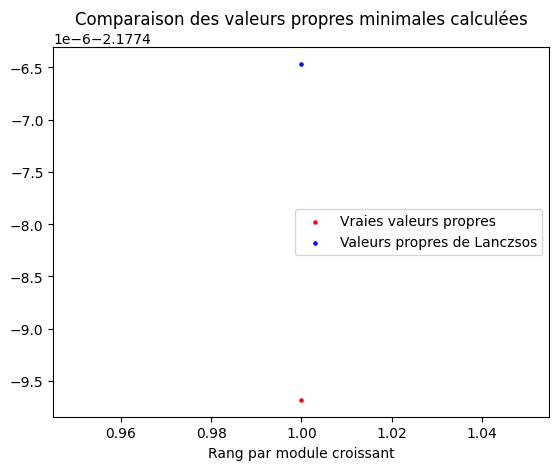

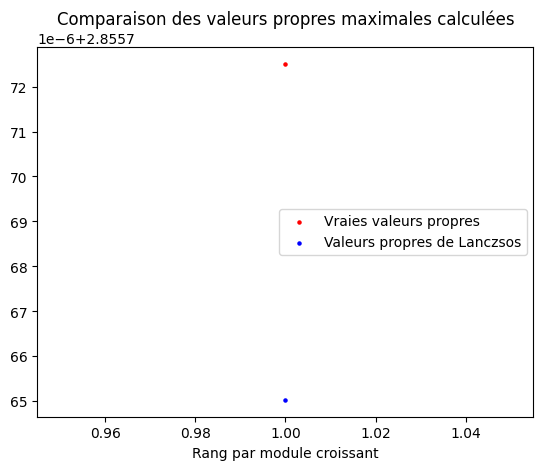

In [28]:
#Test avec diagonalisation
n_vals_sup = 1
n_vals_inf = 1
affiche = True
L_s, L_i, L_v_s, L_v_i = test_lcz(H,m,eps_seuil,init,lanczos_v2, n_vals_sup, n_vals_inf, affiche)


plot_eigs(L_i,L_v_i, True)
plot_eigs(L_s,L_v_s, False)

## Calcul de la fonction de Green

In [29]:
#Formule de Lehmann à recoder

def G_Lehman(valeurs_prop: np.ndarray[float], vecteurs_prop: np.ndarray[float], beta: float, n_site_bain, omegas):
    """ Formule de Lehmann à recoder """
    n_site = n_site_bain + 1
    dim, nb_vp = np.shape(vecteurs_prop)
    N = len(omegas)
    valeurs_prop = valeurs_prop - valeurs_prop[0]
    resu = np.zeros(N,dtype = 'complex_')
    Z = np.sum(np.exp(-beta*(valeurs_prop)))
    S = 0
    somme_coef = 0
    for i in range(nb_vp):
        for j in range(nb_vp):
            prod_scal = 0
            for k in range(2**(2*n_site - 1)):
                sig_k = 2*k + 1
                prod_scal += vecteurs_prop[sig_k, j].conj() * vecteurs_prop[2*k, i]
            prod_scal = np.real(prod_scal)**2 + np.imag(prod_scal)** 2
            somme_coef += (np.exp(-beta*valeurs_prop[i]) + np.exp(-beta*valeurs_prop[j])) * prod_scal
            for n in range(N):
                resu[n] += ((np.exp(-beta*valeurs_prop[i]) + np.exp(-beta*valeurs_prop[j])) * prod_scal ) / (
                        valeurs_prop[j] - valeurs_prop[i] - 1j * omegas[n])
    return -resu/Z


In [30]:
#Fonction spectrale Lehmann
def A_Lehman(valeurs_prop: np.ndarray[float], vecteurs_prop: np.ndarray[float], beta: float, n_site_bain, omegas):
    return - 1 / np.pi * np.imag(G_Lehman(valeurs_prop, vecteurs_prop, beta, n_site_bain, omegas))
    

In [31]:
#Paramètres de calcul de la fonction de Green

def param_Green(init,H,cdagger_0, m, eps):
    """ Calcule l'énergie initiale E_0 et l'état initial \psi_c = c^{\dagger}_0 \psi_0 pour le calcul de la fonction de Green 
    avec excitation particulaire """
    a,b = lanczos_v2(init,h,m,eps)
    T = tridiagonale(a,b,b)
    E_0, F = sp.linalg.eigs(T, which = 'SR', k = 1)
    return (E_0, cdagger_0@F)
    

<>:4: SyntaxWarning: invalid escape sequence '\p'
<>:4: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_15107/2594035351.py:4: SyntaxWarning: invalid escape sequence '\p'
  """ Calcule l'énergie initiale E_0 et l'état initial \psi_c = c^{\dagger}_0 \psi_0 pour le calcul de la fonction de Green


In [45]:
#Opérateurs création et annihilation

def matrice_creation(nqbits, i, spin):
    if spin=="+":
        return FermionHamiltonian(nqbits, [Term([1., "C", i])]).to_spin().get_matrix()
    else:
        return FermionHamiltonian(nqbits, [Term([1., "C", i+1])]).to_spin().get_matrix()

def matrice_annihilation(nqbits, i, spin):
    if spin=="+":
        return FermionHamiltonian(nqbits, [Term([1., "c", i])]).to_spin().get_matrix()
    else:
        return FermionHamiltonian(nqbits, [Term([1., "c", i+1])]).to_spin().get_matrix()
    

In [46]:
#Fonction spectrale Lehmann
def A_Lehman_particulaire_zero_abs(valeurs_prop: np.ndarray[float], vecteurs_prop: np.ndarray[float], beta: float, n_site_bain, omegas):
    return - 1 / np.pi * np.imag(Green_Lehmann_particulaire_zero_abs(valeurs_prop, vecteurs_prop, beta, n_site_bain, omegas))
    

In [47]:
def Green_Lehmann_particulaire_zero_abs(valeurs_prop: np.ndarray[float], vecteurs_prop: np.ndarray[float], mat_nihil, n_site_bain, omegas):
    n_site = n_site_bain + 1
    dim, nb_vp = np.shape(vecteurs_prop)
    N = len(omegas)
    valeurs_prop = valeurs_prop - valeurs_prop[0]
    resu = np.zeros(N,dtype = 'complex_')
    S = 0
    for n in range(nb_vp):
            prod_scal = vecteurs_prop[0].T @ mat_nihil @ vecteurs_prop[n]
            prod_scal = np.real(prod_scal)**2 + np.imag(prod_scal)** 2
            S += ( prod_scal ) / (
                        valeurs_prop[0] - valeurs_prop[n] + omegas[n])
    return S

In [48]:
#Affichage de la fonction de Green
def plot_spectrales(inf,sup,n_vals,eta, n_site_bain):
    valeurs_prop, vecteurs_prop = np.linalg.eigh(H)
    Omega = np.linspace(inf,sup, n_vals)
    Eta = eta * np.ones_like(Z)
    
    Y1 = spectraleLanczos(Omega, Eta, psi_c, E_0, H, m, eps_seuil)
    Y2 = np.abs(A_Lehman_particulaire_zero_abs(valeurs_prop, vecteurs_prop, n_site_bain, Omega + 1j * Eta)) ## VALEUR ABSOLUE
    
    plt.figure()
    plt.title("Spectre approché de la fonction de Green")
    plt.xlabel(r"$\omega$")
    plt.ylabel(r"$A(\omega + i \eta)$")
    plt.plot(Omega,Y1, color = 'r', label = "Spectre approché")
    plt.plot(Omega, Y2, color = 'b', label = "Spectre exact (valeur abs)")
    plt.legend()
    
    plt.show()
    return

In [49]:
a,b = lanczos_v2(init,H,m,eps_seuil)

inf = -100
sup = 100
n_vals = 100
eta = 0.049
cdagger_0 = matrice_creation(N_sys, 0, "+")
psi_c, E_0 = param_Green(init,H,cdagger_0, m, eps)

plot_spectrales(inf,sup,n_vals,eta, n_bain)




TypeError: __init__() takes at least 4 positional arguments (2 given)

In [1]:
def test():
    return 1